In [2]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import urllib.request
import xarray as xr
import geopandas as gpd
import rioxarray as rio
from shapely.geometry import mapping, Polygon
import cartopy.crs as ccrs
import calendar
import matplotlib as mpl
import xarray as xr
import time

C:\Users\HP\AppData\Roaming\Python\Python39\site-packages\geopandas\_compat.py:124: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [3]:
import os
wd = "F:/Masters/ML in Civil and Env/"
os.listdir(wd)

['Chennai_Meenambakkam.csv',
 'CMIP6_ET0_0.5_SD.pdf',
 'CMIP6_ET0_PET_SD.pdf',
 'CMIP6_ET0_SEA.pdf',
 'CMIP6_SD_Senegal.pdf',
 'Commentary.docx',
 'Commentary_ET.docx',
 'Coursework',
 'dataset',
 'Images',
 'Literature',
 'Maaz-Presentation.pptx',
 'Manuscript.docx',
 'Manuscript_SD.docx',
 'ML_models',
 'PET_GCM_Infographic.png',
 'Saudi_ET_paper_2010.pdf',
 'Saudi_Shapefile',
 'Saudi_Shapefile.zip',
 'SD_Paper.pdf',
 'SD_Paper2.pdf',
 'SD_Paper3.pdf',
 'SD_paper_ref.pdf',
 'stacked_dataset.csv',
 '~$mmentary.docx']

In [21]:
def r_squared(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[1][0]
    r2 = r**2
    return r2

def r_coef(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[1][0]
    return r

def rmse(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    return rmse

def mae(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    return mae

def mape(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mape

def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    nash = 1 - (ss_res / ss_total)
    return nash

def md(y_true, y_pred):
    md = 1 - (np.sum((y_true - y_pred)**2) / np.sum((np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))**2))
    return md

def kge_metrics(y_true, y_pred):
    kge = 1 - ((((r_coef(y_true, y_pred))-1)**2)+(((np.std(y_true)/np.std(y_pred))-1)**2)+(((np.mean(y_true)/np.mean(y_true))-1)**2))**0.5
    return kge

In [22]:
def r_squared_spatial(y_true, y_pred):
    r = xr.corr(y_true, y_pred, dim='time')
    r2 = r**2
    return r2

def r_coef_spatial(y_true, y_pred):
    r = xr.corr(y_true, y_pred, dim='time')
    return r

def rmse_spatial(y_true, y_pred):
    rmse = np.sqrt((y_true - y_pred)**2).mean(dim='time')
    return rmse

def mae_spatial(y_true, y_pred):
    mae = (np.abs(y_true - y_pred)).mean(dim='time')
    return mae

def kge_spatial(y_true, y_pred):
    kge = 1-((((r_coef_spatial(y_true, y_pred))-1)**2)+((((y_true.std(dim='time'))/(y_pred.std(dim='time')))-1)**2)+((((y_true.mean(dim='time'))/(y_true.mean(dim='time')))-1)*2))**0.5
    return kge

In [6]:
ds_hist = xr.open_dataset(wd+"dataset/saudi_final_dataset2.nc")
ds_126 = xr.open_dataset(wd+"dataset/saudi_ssp126_final_dataset.nc")
ds_245 = xr.open_dataset(wd+"dataset/saudi_ssp245_final_dataset.nc")
ds_370 = xr.open_dataset(wd+"dataset/saudi_ssp370_final_dataset.nc")
ds_585 = xr.open_dataset(wd+"dataset/saudi_ssp585_final_dataset.nc")

In [7]:
df_hist = ds_hist.to_dataframe().reset_index()
df_126 = ds_126.to_dataframe().reset_index()
df_245 = ds_245.to_dataframe().reset_index()
df_370 = ds_370.to_dataframe().reset_index()
df_585 = ds_585.to_dataframe().reset_index()

In [8]:
df_hist.pop('spatial_ref')
df_126.pop('spatial_ref')
df_245.pop('spatial_ref')
df_370.pop('spatial_ref')
df_585.pop('spatial_ref')

0           0
1           0
2           0
3           0
4           0
           ..
45532867    0
45532868    0
45532869    0
45532870    0
45532871    0
Name: spatial_ref, Length: 45532872, dtype: int32

In [9]:
print(df_hist.isnull().sum())
print(df_126.isnull().sum())

time              0
lon               0
lat               0
tasmax     11247180
tasmin     11247180
tas        11247180
rsdt       11247180
sfcWind    11247180
hurs       11247180
pet        11247180
aet        11247180
dtype: int64
time              0
lon               0
lat               0
tasmax     27425400
tasmin     27425400
tas        27425400
rsdt       27425400
sfcWind    27425400
hurs       27425400
dtype: int64


In [10]:
df_126 = df_126.dropna()
df_245 = df_245.dropna()
df_370 = df_370.dropna()
df_585 = df_585.dropna()
df_hist = df_hist.dropna()

df_126.to_csv(wd+"stacked_126_dataset.csv")
df_245.to_csv(wd+"stacked_245_dataset.csv")
df_370.to_csv(wd+"stacked_370_dataset.csv")
df_585.to_csv(wd+"stacked_585_dataset.csv")

In [11]:
df_early_126 = df_126[(df_126['time'] < '2051-01-01')]
df_late_126 = df_126[(df_126['time'] >= '2051-01-01')]
df_early_245 = df_245[(df_245['time'] < '2051-01-01')]
df_late_245 = df_245[(df_245['time'] >= '2051-01-01')]
df_early_370 = df_370[(df_370['time'] < '2051-01-01')]
df_late_370 = df_370[(df_370['time'] >= '2051-01-01')]
df_early_585 = df_585[(df_585['time'] < '2051-01-01')]
df_late_585 = df_585[(df_585['time'] >= '2051-01-01')]

In [12]:
from xgboost import XGBRegressor

pet_model = XGBRegressor()
pet_model.load_model(wd+'ML_models/xgb_pet_model.json')

aet_model = XGBRegressor()
aet_model.load_model(wd+'ML_models/xgb_aet_model.json')

###### Check the models

In [17]:
X_Test = df_hist.drop(['time','pet', 'aet'],axis=1)
Y_Test = df_hist['pet']
Y2_Test = df_hist['aet']

In [24]:
y_xgb_test = pet_model.predict(X_Test)
print(f"R-squared (R2): Test {r_squared(Y_Test, y_xgb_test)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(Y_Test, y_xgb_test)}")
print(f"Mean Absolute Error (MAE): Test {mae(Y_Test, y_xgb_test)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(Y_Test, y_xgb_test)}")

R-squared (R2): Test 0.8949064187786794
Root Mean Squared Error (RMSE): Test 16.075159924603007
Mean Absolute Error (MAE): Test 12.220913887023926
Kling-Gupta Efficiency (KGE): Test 0.9251269949184372


In [25]:
y_xgb_test = aet_model.predict(X_Test)
print(f"R-squared (R2): Test {r_squared(Y2_Test, y_xgb_test)}")
print(f"Root Mean Squared Error (RMSE): Test {rmse(Y2_Test, y_xgb_test)}")
print(f"Mean Absolute Error (MAE): Test {mae(Y2_Test, y_xgb_test)}")
print(f"Kling-Gupta Efficiency (KGE): Test {kge_metrics(Y2_Test, y_xgb_test)}")

R-squared (R2): Test 0.46374213388058694
Root Mean Squared Error (RMSE): Test 4.030055379179414
Mean Absolute Error (MAE): Test 2.3698439598083496
Kling-Gupta Efficiency (KGE): Test 0.47682044036555615


###### Future Predictions

In [28]:
X_early_126 = df_early_126.drop(['time'],axis=1)
X_late_126 = df_late_126.drop(['time'],axis=1)
ETp_early_126 = pet_model.predict(X_early_126)
ETp_late_126 = pet_model.predict(X_late_126)
ETa_early_126 = aet_model.predict(X_early_126)
ETa_late_126 = aet_model.predict(X_late_126)

In [31]:
X_early_245 = df_early_245.drop(['time'],axis=1)
X_late_245 = df_late_245.drop(['time'],axis=1)
ETp_early_245 = pet_model.predict(X_early_245)
ETp_late_245 = pet_model.predict(X_late_245)
ETa_early_245 = aet_model.predict(X_early_245)
ETa_late_245 = aet_model.predict(X_late_245)

In [32]:
X_early_370 = df_early_370.drop(['time'],axis=1)
X_late_370 = df_late_370.drop(['time'],axis=1)
ETp_early_370 = pet_model.predict(X_early_370)
ETp_late_370 = pet_model.predict(X_late_370)
ETa_early_370 = aet_model.predict(X_early_370)
ETa_late_370 = aet_model.predict(X_late_370)

In [33]:
X_early_585 = df_early_585.drop(['time'],axis=1)
X_late_585 = df_late_585.drop(['time'],axis=1)
ETp_early_585 = pet_model.predict(X_early_585)
ETp_late_585 = pet_model.predict(X_late_585)
ETa_early_585 = aet_model.predict(X_early_585)
ETa_late_585 = aet_model.predict(X_late_585)

###### Saving the future files

In [38]:
df_early_126.insert(column = "ETp", value = ETp_early_126, loc = len(df_early_126.columns))
df_late_126.insert(column = "ETp", value = ETp_late_126, loc = len(df_late_126.columns))
df_early_126.insert(column = "ETa", value = ETa_early_126, loc = len(df_early_126.columns))
df_late_126.insert(column = "ETa", value = ETa_late_126, loc = len(df_late_126.columns))
df_early_245.insert(column = "ETp", value = ETp_early_245, loc = len(df_early_245.columns))
df_late_245.insert(column = "ETp", value = ETp_late_245, loc = len(df_late_245.columns))
df_early_245.insert(column = "ETa", value = ETa_early_245, loc = len(df_early_245.columns))
df_late_245.insert(column = "ETa", value = ETa_late_245, loc = len(df_late_245.columns))
df_early_370.insert(column = "ETp", value = ETp_early_370, loc = len(df_early_370.columns))
df_late_370.insert(column = "ETp", value = ETp_late_370, loc = len(df_late_370.columns))
df_early_370.insert(column = "ETa", value = ETa_early_370, loc = len(df_early_370.columns))
df_late_370.insert(column = "ETa", value = ETa_late_370, loc = len(df_late_370.columns))
df_early_585.insert(column = "ETp", value = ETp_early_585, loc = len(df_early_585.columns))
df_late_585.insert(column = "ETp", value = ETp_late_585, loc = len(df_late_585.columns))
df_early_585.insert(column = "ETa", value = ETa_early_585, loc = len(df_early_585.columns))
df_late_585.insert(column = "ETa", value = ETa_late_585, loc = len(df_late_585.columns))

In [42]:
DF_Early_126 = df_early_126[['time', 'lat', 'lon','ETp', 'ETa']]
DF_Late_126 = df_late_126[['time', 'lat', 'lon','ETp', 'ETa']]
DF_Early_245 = df_early_245[['time', 'lat', 'lon','ETp', 'ETa']]
DF_Late_245 = df_late_245[['time', 'lat', 'lon','ETp', 'ETa']]
DF_Early_370 = df_early_370[['time', 'lat', 'lon','ETp', 'ETa']]
DF_Late_370 = df_late_370[['time', 'lat', 'lon','ETp', 'ETa']]
DF_Early_585 = df_early_585[['time', 'lat', 'lon','ETp', 'ETa']]
DF_Late_585 = df_late_585[['time', 'lat', 'lon','ETp', 'ETa']]

In [44]:
DF_Early_126

,time,lat,lon,ETp,ETa
1286,2015-01-31,28.0,34.6,110.516251,0.935694
1287,2015-01-31,28.1,34.6,109.964836,0.619489
1288,2015-01-31,28.2,34.6,110.914436,1.267169
1478,2015-01-31,28.1,34.7,117.848251,0.715278
1479,2015-01-31,28.2,34.7,118.797852,1.267169
...,...,...,...,...,...
19057484,2050-12-31,21.7,55.6,80.644440,-0.383922
19057485,2050-12-31,21.8,55.6,79.848122,-0.421659
19057486,2050-12-31,21.9,55.6,79.590523,-0.421659
19057487,2050-12-31,22.0,55.6,77.792274,-0.421659


In [46]:
DF_Early_126

ETp       ETa
time       lat  lon                       
2015-01-31 28.0 34.6  110.516251  0.935694
           28.1 34.6  109.964836  0.619489
           28.2 34.6  110.914436  1.267169
           28.1 34.7  117.848251  0.715278
           28.2 34.7  118.797852  1.267169
...                          ...       ...
2050-12-31 21.7 55.6   80.644440 -0.383922
           21.8 55.6   79.848122 -0.421659
           21.9 55.6   79.590523 -0.421659
           22.0 55.6   77.792274 -0.421659
           22.1 55.6   76.428101 -0.642619

[7579872 rows x 2 columns]

In [45]:
DF_Early_126 = DF_Early_126.set_index(['time','lat','lon'])
DF_Late_126 = DF_Late_126.set_index(['time','lat','lon'])
DF_Early_245 = DF_Early_245.set_index(['time','lat','lon'])
DF_Late_245 = DF_Late_245.set_index(['time','lat','lon'])
DF_Early_370 = DF_Early_370.set_index(['time','lat','lon'])
DF_Late_370 = DF_Late_370.set_index(['time','lat','lon'])
DF_Early_585 = DF_Early_585.set_index(['time','lat','lon'])
DF_Late_585 = DF_Late_585.set_index(['time','lat','lon'])

In [47]:
ds_early_126 = xr.Dataset.from_dataframe(DF_Early_126)
ds_late_126 = xr.Dataset.from_dataframe(DF_Late_126)
ds_early_245 = xr.Dataset.from_dataframe(DF_Early_245)
ds_late_245 = xr.Dataset.from_dataframe(DF_Late_245)
ds_early_370 = xr.Dataset.from_dataframe(DF_Early_370)
ds_late_370 = xr.Dataset.from_dataframe(DF_Late_370)
ds_early_585 = xr.Dataset.from_dataframe(DF_Early_585)
ds_late_585 = xr.Dataset.from_dataframe(DF_Late_585)

In [48]:
ds_early_126.to_netcdf(wd+'output/et_mon_saudi_ssp126_2015-2050.nc')
ds_late_126.to_netcdf(wd+'output/et_mon_saudi_ssp126_2051-2100.nc')
ds_early_245.to_netcdf(wd+'output/et_mon_saudi_ssp245_2015-2050.nc')
ds_late_245.to_netcdf(wd+'output/et_mon_saudi_ssp245_2051-2100.nc')
ds_early_370.to_netcdf(wd+'output/et_mon_saudi_ssp370_2015-2050.nc')
ds_late_370.to_netcdf(wd+'output/et_mon_saudi_ssp370_2051-2100.nc')
ds_early_585.to_netcdf(wd+'output/et_mon_saudi_ssp585_2015-2050.nc')
ds_late_585.to_netcdf(wd+'output/et_mon_saudi_ssp585_2051-2100.nc')

In [49]:
ds_early_126

<xarray.Dataset>
Dimensions:  (time: 432, lat: 158, lon: 211)
Coordinates:
  * time     (time) datetime64[ns] 2015-01-31 2015-02-28 ... 2050-12-31
  * lat      (lat) float64 16.4 16.5 16.6 16.7 16.8 ... 31.7 31.8 31.9 32.0 32.1
  * lon      (lon) float64 34.6 34.7 34.8 34.9 35.0 ... 55.2 55.3 55.4 55.5 55.6
Data variables:
    ETp      (time, lat, lon) float32 nan nan nan nan nan ... nan nan nan nan
    ETa      (time, lat, lon) float32 nan nan nan nan nan ... nan nan nan nan

In [50]:
ds_hist

<xarray.Dataset>
Dimensions:      (time: 420, lon: 231, lat: 191)
Coordinates:
  * time         (time) datetime64[ns] 1980-01-31 1980-02-29 ... 2014-12-31
  * lon          (lon) float64 34.0 34.1 34.2 34.3 34.4 ... 56.7 56.8 56.9 57.0
  * lat          (lat) float64 14.0 14.1 14.2 14.3 14.4 ... 32.7 32.8 32.9 33.0
Data variables:
    spatial_ref  int32 0
    tasmax       (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    tasmin       (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    tas          (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    rsdt         (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    sfcWind      (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    hurs         (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    pet          (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan
    aet          (time, lat, lon) float32 nan nan nan nan ... nan nan nan nan

In [71]:
diff_ETp_126_early = ds_early_126['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETp_126_late = ds_late_126['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETa_126_early = ds_early_126['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])
diff_ETa_126_late = ds_late_126['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])
diff_ETp_245_early = ds_early_245['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETp_245_late = ds_late_245['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETa_245_early = ds_early_245['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])
diff_ETa_245_late = ds_late_245['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])
diff_ETp_370_early = ds_early_370['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETp_370_late = ds_late_370['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETa_370_early = ds_early_370['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])
diff_ETa_370_late = ds_late_370['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])
diff_ETp_585_early = ds_early_585['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETp_585_late = ds_late_585['ETp'].mean(dim=['time'])-ds_hist['pet'].mean(dim=['time'])
diff_ETa_585_early = ds_early_585['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])
diff_ETa_585_late = ds_late_585['ETa'].mean(dim=['time'])-ds_hist['aet'].mean(dim=['time'])

In [55]:
saudi_s = gpd.read_file("F:/Masters/Thesis/Saudi_Shapefile/")
saudi_poly = saudi_s.geometry
saudi=gpd.clip(saudi_s,saudi_poly) 
saudi.geometry

0    MULTIPOLYGON (((50.88101 24.63640, 50.92860 24...
Name: geometry, dtype: geometry

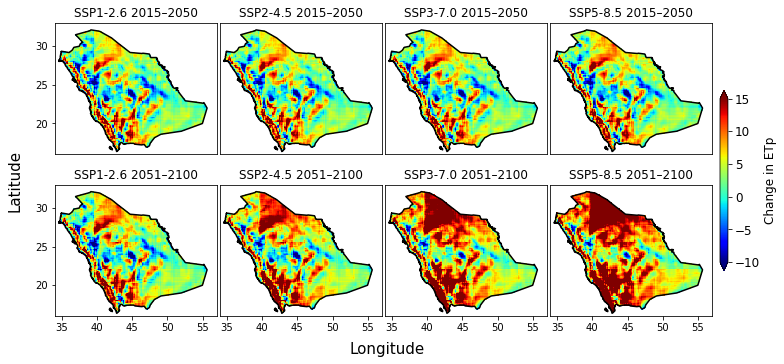

In [82]:
fig, axes = plt.subplots(nrows = 2,ncols = 4, figsize = (11,5))
fig.set_facecolor("white")
plt.subplots_adjust(bottom=0.11, top=0.95, left=0.08, right=0.91, hspace=0.15, wspace = 0.02)

v_min = -10
v_max = 15
c_map = "jet"
factor = 1

axes[0,0].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_126_early, vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,0].set_title("SSP1-2.6 2015–2050", fontsize = 12)
axes[0,0].set_xticks([])
axes[0,0].set_ylim((16,33))
axes[0,0].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,0],color='black')

axes[0,1].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_245_early, vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,1].set_title("SSP2-4.5 2015–2050", fontsize = 12)
axes[0,1].set_xticks([])
axes[0,1].set_yticks([])
axes[0,1].set_ylim((16,33))
axes[0,1].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,1],color='black')


axes[0,2].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_370_early,vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,2].set_title("SSP3-7.0 2015–2050", fontsize = 12)
axes[0,2].set_xticks([])
axes[0,2].set_yticks([])
axes[0,2].set_ylim((16,33))
axes[0,2].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,2],color='black')

axes[0,3].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_585_early, vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,3].set_title("SSP5-8.5 2015–2050", fontsize = 12)
axes[0,3].set_xticks([])
axes[0,3].set_yticks([])
axes[0,3].set_ylim((16,33))
axes[0,3].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,3],color='black')
    
axes[1,0].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_126_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,0].set_title("SSP1-2.6 2051–2100", fontsize = 12)
axes[1,0].set_ylim((16,33))
axes[1,0].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,0],color='black')

axes[1,1].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_245_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,1].set_title("SSP2-4.5 2051–2100", fontsize = 12)
axes[1,1].set_yticks([])
axes[1,1].set_ylim((16,33))
axes[1,1].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,1],color='black')
 
axes[1,2].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_370_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,2].set_title("SSP3-7.0 2051–2100", fontsize = 12)
axes[1,2].set_yticks([])
axes[1,2].set_ylim((16,33))
axes[1,2].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,2],color='black')

axes[1,3].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETp_585_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,3].set_title("SSP5-8.5 2051–2100", fontsize = 12)
axes[1,3].set_yticks([])
axes[1,3].set_ylim((16,33))
axes[1,3].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,3],color='black')

norm = mpl.colors.Normalize(vmin=v_min, vmax=v_max)
cax = fig.add_axes([0.92, 0.25, 0.010, 0.50])
cb = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = c_map),cax=cax, orientation='vertical', extend = 'both')
cb.ax.tick_params(labelsize=12)
cb.set_label(label="Change in ETp", color = 'k', size=12)

fig.supxlabel('Longitude', fontsize = 15)
fig.supylabel('Latitude', fontsize = 15)

plt.savefig(wd+'Images/ETp_difference.png', format = 'png', dpi = 500)

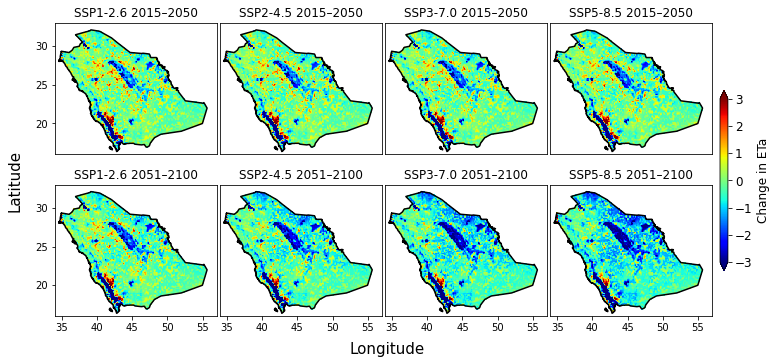

In [83]:
fig, axes = plt.subplots(nrows = 2,ncols = 4, figsize = (11,5))
fig.set_facecolor("white")
plt.subplots_adjust(bottom=0.11, top=0.95, left=0.08, right=0.91, hspace=0.15, wspace = 0.02)

v_min = -3
v_max = 3
c_map = "jet"
factor = 1

axes[0,0].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_126_early, vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,0].set_title("SSP1-2.6 2015–2050", fontsize = 12)
axes[0,0].set_xticks([])
axes[0,0].set_ylim((16,33))
axes[0,0].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,0],color='black')

axes[0,1].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_245_early, vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,1].set_title("SSP2-4.5 2015–2050", fontsize = 12)
axes[0,1].set_xticks([])
axes[0,1].set_yticks([])
axes[0,1].set_ylim((16,33))
axes[0,1].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,1],color='black')

axes[0,2].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_370_early,vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,2].set_title("SSP3-7.0 2015–2050", fontsize = 12)
axes[0,2].set_xticks([])
axes[0,2].set_yticks([])
axes[0,2].set_ylim((16,33))
axes[0,2].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,2],color='black')

axes[0,3].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_585_early, vmin=v_min, vmax=v_max, cmap = c_map)
axes[0,3].set_title("SSP5-8.5 2015–2050", fontsize = 12)
axes[0,3].set_xticks([])
axes[0,3].set_yticks([])
axes[0,3].set_ylim((16,33))
axes[0,3].set_xlim((34,57))
saudi.boundary.plot(ax=axes[0,3],color='black')
    
axes[1,0].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_126_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,0].set_title("SSP1-2.6 2051–2100", fontsize = 12)
axes[1,0].set_ylim((16,33))
axes[1,0].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,0],color='black')

axes[1,1].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_245_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,1].set_title("SSP2-4.5 2051–2100", fontsize = 12)
axes[1,1].set_yticks([])
axes[1,1].set_ylim((16,33))
axes[1,1].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,1],color='black')
 
axes[1,2].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_370_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,2].set_title("SSP3-7.0 2051–2100", fontsize = 12)
axes[1,2].set_yticks([])
axes[1,2].set_ylim((16,33))
axes[1,2].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,2],color='black')

axes[1,3].pcolormesh(ds_early_126.lon, ds_early_126.lat, diff_ETa_585_late, vmin=v_min, vmax=v_max, cmap = c_map)
axes[1,3].set_title("SSP5-8.5 2051–2100", fontsize = 12)
axes[1,3].set_yticks([])
axes[1,3].set_ylim((16,33))
axes[1,3].set_xlim((34,57))
saudi.boundary.plot(ax=axes[1,3],color='black')

norm = mpl.colors.Normalize(vmin=v_min, vmax=v_max)
cax = fig.add_axes([0.92, 0.25, 0.010, 0.50])
cb = plt.colorbar(plt.cm.ScalarMappable(norm = norm, cmap = c_map),cax=cax, orientation='vertical', extend = 'both')
cb.ax.tick_params(labelsize=12)
cb.set_label(label="Change in ETa", color = 'k', size=12)

fig.supxlabel('Longitude', fontsize = 15)
fig.supylabel('Latitude', fontsize = 15)

plt.savefig(wd+'Images/ETa_difference.png', format = 'png', dpi = 500)